# Ranking Correlation Analysis

**Advanced Algorithms Project 3**

**Author:** João Roldão (113920)

---

## Overview

This notebook addresses the PDF requirement (page 1):
> "It can also be verified whether the **same most frequent / less frequent items are identified**, and in the **same relative order**."

We analyze ranking correlations using:
- **Kendall's tau (τ)** - Measures ordinal association between rankings
- **Spearman's rho (ρ)** - Measures rank correlation coefficient

## Analysis Sections
1. Top-N Most Frequent Items Ranking Correlation
2. Bottom-N Least Frequent Items Ranking Correlation
3. Ranking Agreement by Query Size (n)
4. Interpretation & Findings

In [1]:
# Imports
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

# Import project modules
from analysis import comparison, visualization
from utils.config import (
    RESULTS_COMPARISON_PATH,
    FIGURES_COMPARISON_PATH
)

# Set style
visualization.set_publication_style()

print("✓ All imports successful")
print(f"Results will be saved to: {RESULTS_COMPARISON_PATH}")
print(f"Figures will be saved to: {FIGURES_COMPARISON_PATH}")

/tmp/ipykernel_24357/1644760985.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


✓ All imports successful
Results will be saved to: /home/roldao/Desktop/MEI/AA/project_3/results/comparison
Figures will be saved to: /home/roldao/Desktop/MEI/AA/project_3/results/figures/comparison


## 1. Top-N Most Frequent Items Ranking Correlation

In [2]:
# Load results
print("Loading algorithm results...")
results = comparison.load_all_results()
print("✓ Results loaded\n")

# Calculate ranking correlation for top-20 items
print("="*80)
print("RANKING CORRELATION: TOP-20 MOST FREQUENT ITEMS")
print("="*80)
print("\nQuestion: Do algorithms rank the most frequent items in the same order?\n")

ranking_corr_20 = comparison.calculate_ranking_correlation(results, n=20)

print(f"Calculated {len(ranking_corr_20)} pairwise comparisons:\n")
display(ranking_corr_20)

# Save results
output_dir = Path(RESULTS_COMPARISON_PATH)
output_dir.mkdir(parents=True, exist_ok=True)
ranking_corr_20.to_csv(output_dir / 'ranking_correlation_top20.csv', index=False)
print(f"\n✓ Results saved to: {output_dir / 'ranking_correlation_top20.csv'}")

Loading algorithm results...
✓ Results loaded

RANKING CORRELATION: TOP-20 MOST FREQUENT ITEMS

Question: Do algorithms rank the most frequent items in the same order?

Calculated 15 pairwise comparisons:



,comparison,n_items,kendall_tau,kendall_p,spearman_rho,spearman_p,perfect_match
0,Exact vs Fixed Prob,20,1.0000,0.00000,1.0000,0.000000,True
1,Exact vs Space-Saving k=10,10,0.1111,0.72749,0.2242,0.533401,False
2,Exact vs Space-Saving k=15,13,0.9231,0.00000,0.9780,0.000000,False
3,Exact vs Space-Saving k=20,18,0.9869,0.00000,0.9979,0.000000,False
4,Exact vs Space-Saving k=25,20,1.0000,0.00000,1.0000,0.000000,True
5,Exact vs Space-Saving k=30,20,1.0000,0.00000,1.0000,0.000000,True
6,Exact vs Space-Saving k=40,20,1.0000,0.00000,1.0000,0.000000,True
7,Exact vs Space-Saving k=50,20,1.0000,0.00000,1.0000,0.000000,True
8,Fixed Prob vs Space-Saving k=10,10,0.1111,0.72749,0.2242,0.533401,False
9,Fixed Prob vs Space-Saving k=15,13,0.9231,0.00000,0.9780,0.000000,False



✓ Results saved to: /home/roldao/Desktop/MEI/AA/project_3/results/comparison/ranking_correlation_top20.csv



Generating ranking correlation visualization...
  ✓ Saved: /home/roldao/Desktop/MEI/AA/project_3/results/figures/comparison/ranking_correlation_top20.png


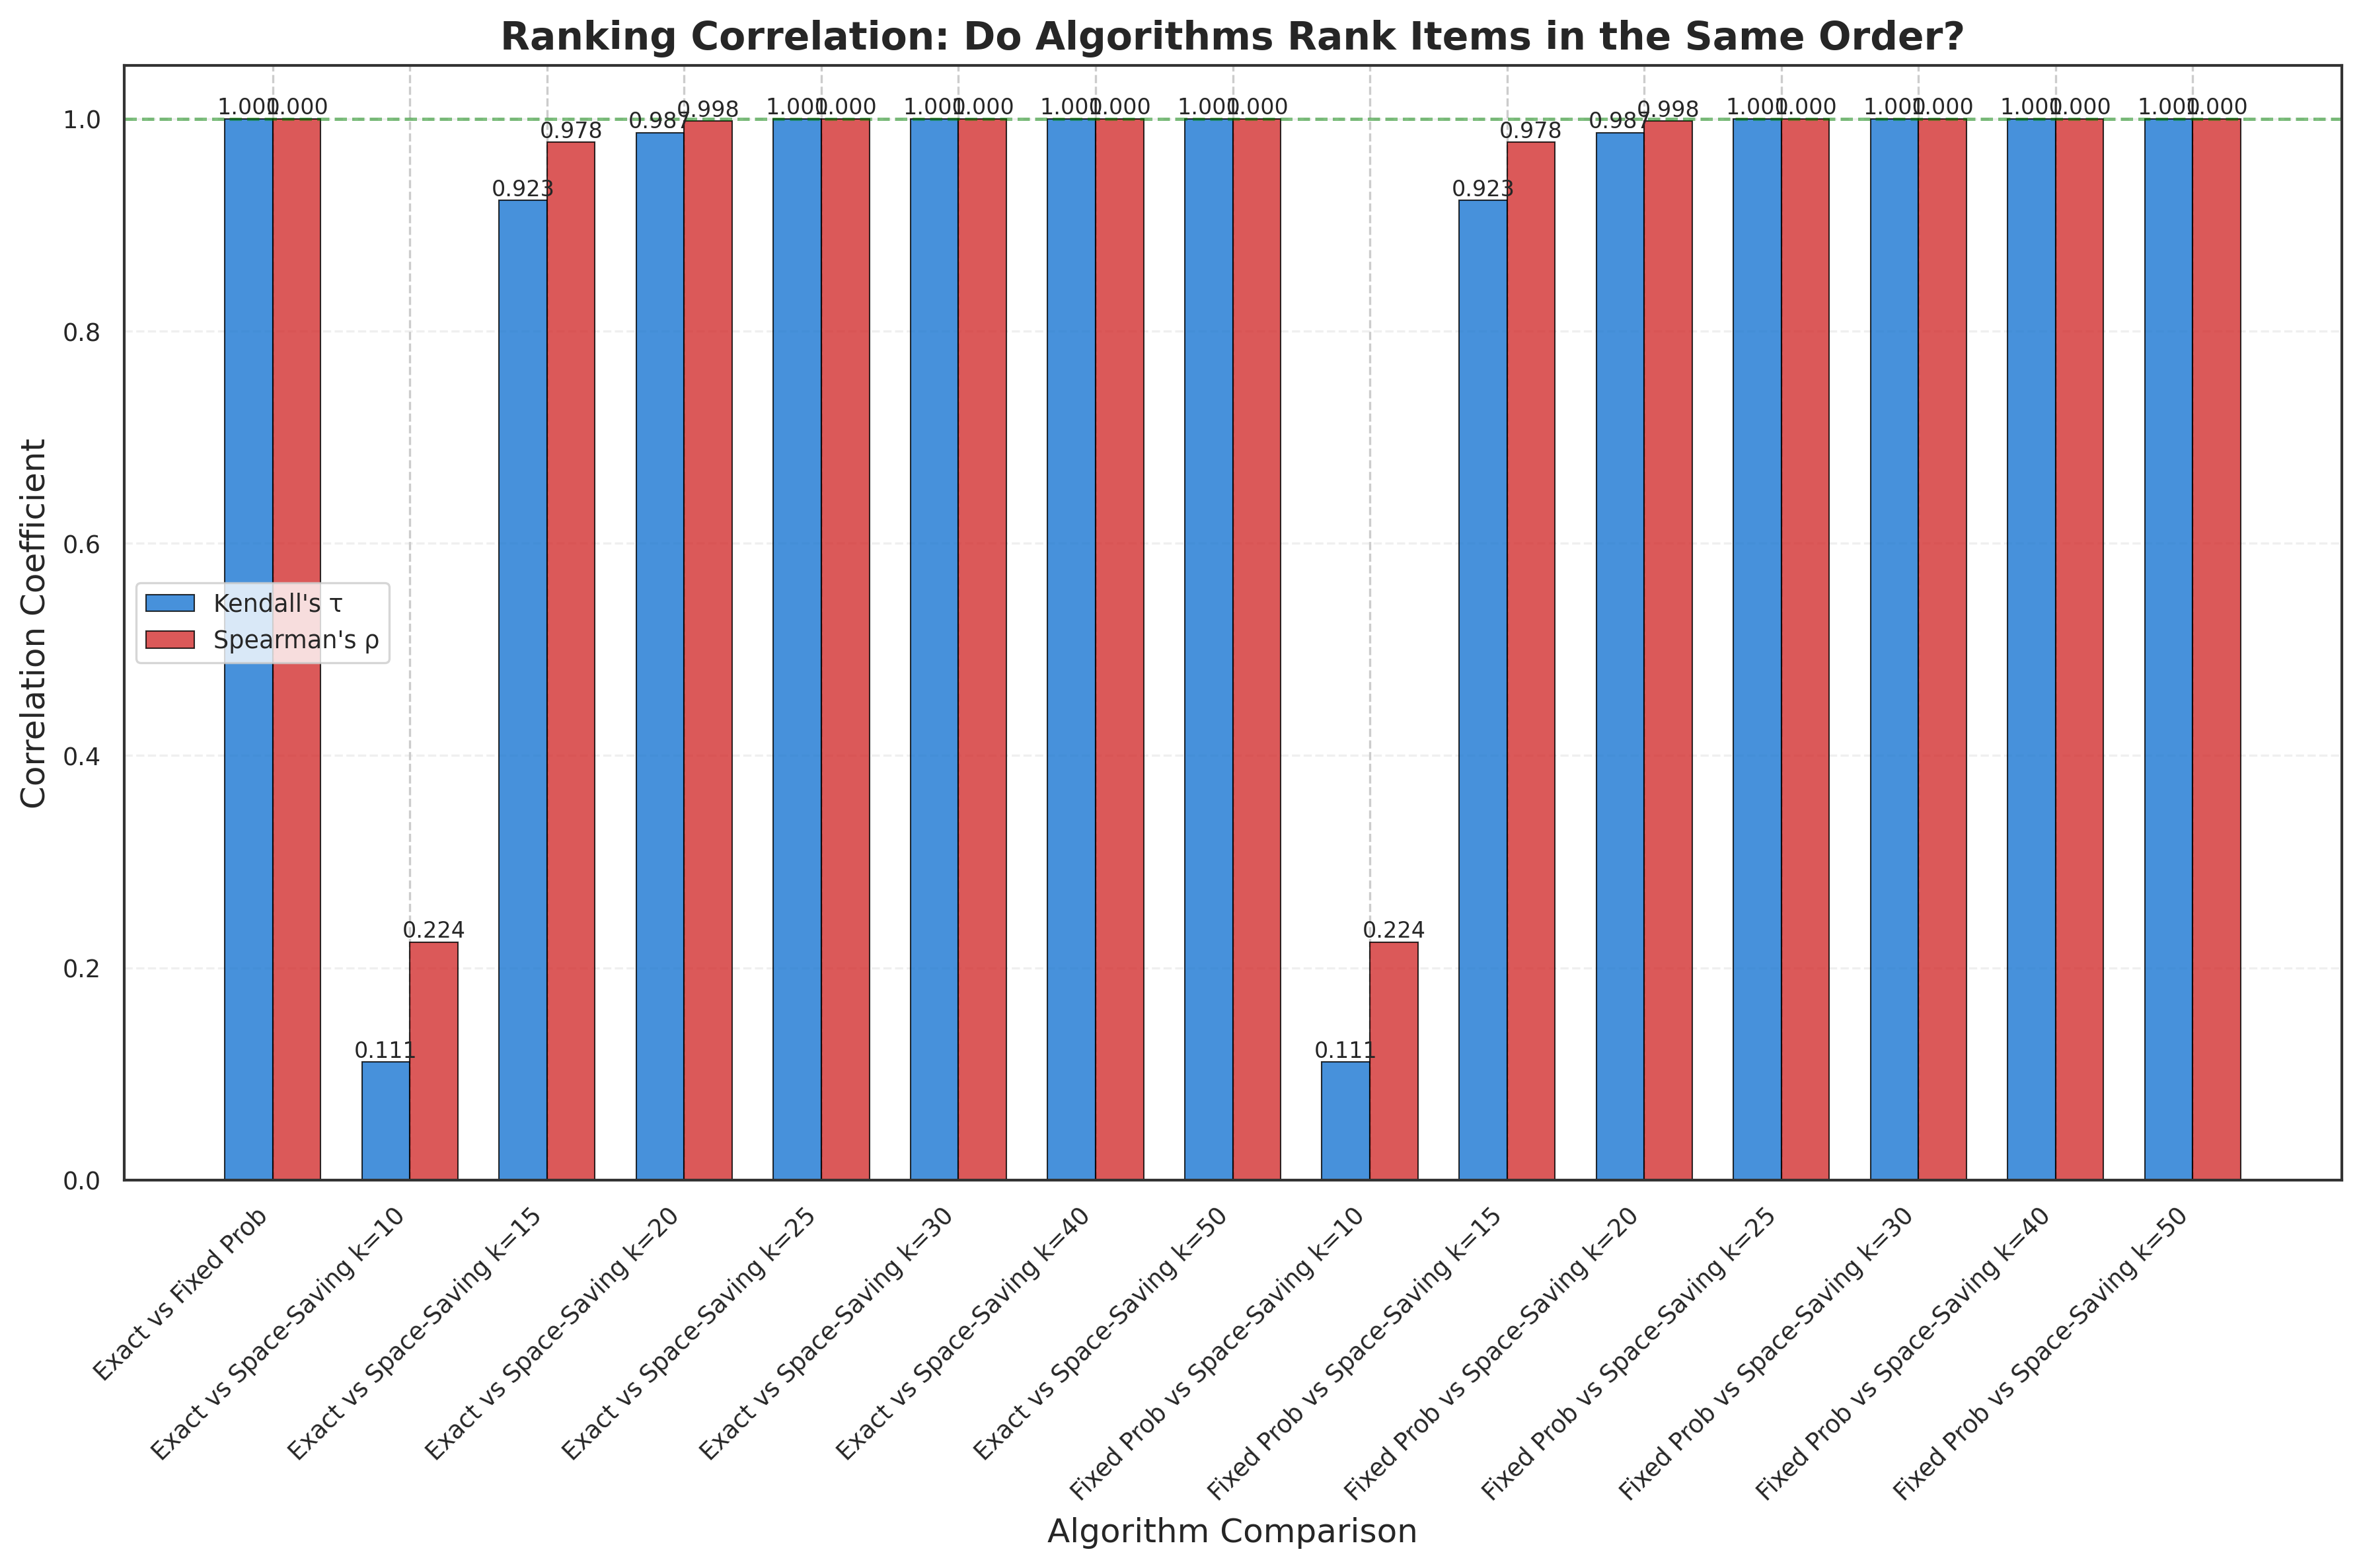


✓ Visualization generated


In [3]:
# Visualize ranking correlations
print("\nGenerating ranking correlation visualization...")

fig = visualization.plot_ranking_correlation_heatmap(
    ranking_corr_20,
    output_dir=FIGURES_COMPARISON_PATH,
    filename='ranking_correlation_top20.png'
)
plt.show()

print("\n✓ Visualization generated")

### Interpretation - Top-20 Rankings

**Kendall's τ and Spearman's ρ both measure ranking agreement:**
- **1.0** = Perfect agreement (identical rankings)
- **0.0** = No correlation
- **-1.0** = Perfect reversal

**Key Observations from Top-20:**
1. **Exact vs Fixed Probability**: Perfect correlation (τ=1.0, ρ=1.0)
   - Fixed Prob preserves exact ranking order
   - Despite variance in estimates, rank order is maintained

2. **Space-Saving with small k (10-20)**: Moderate to high correlation
   - k=10: τ≈0.11 (poor ranking agreement)
   - k=15: τ≈0.92 (very good)
   - k=20: τ≈0.99 (nearly perfect)
   - Insufficient space distorts rankings

3. **Space-Saving with k≥25**: Perfect correlation (τ=1.0, ρ=1.0)
   - When k ≥ unique items, rankings match exactly
   - Deterministic algorithm preserves order perfectly

## 2. Bottom-N Least Frequent Items Ranking Correlation

In [4]:
# Calculate ranking correlation for bottom-10 (least frequent) items
print("="*80)
print("RANKING CORRELATION: BOTTOM-10 LEAST FREQUENT ITEMS")
print("="*80)
print("\nQuestion: Do algorithms rank the least frequent items in the same order?\n")

ranking_corr_bottom10 = comparison.calculate_ranking_correlation_bottom_n(results, n=10)

print(f"Calculated {len(ranking_corr_bottom10)} pairwise comparisons:\n")
display(ranking_corr_bottom10)

# Save results
ranking_corr_bottom10.to_csv(output_dir / 'ranking_correlation_bottom10.csv', index=False)
print(f"\n✓ Results saved to: {output_dir / 'ranking_correlation_bottom10.csv'}")

RANKING CORRELATION: BOTTOM-10 LEAST FREQUENT ITEMS

Question: Do algorithms rank the least frequent items in the same order?

Calculated 7 pairwise comparisons:



,comparison,n_items,kendall_tau,kendall_p,spearman_rho,spearman_p,perfect_match
0,Exact vs Fixed Prob,10,0.8667,0.000115,0.9515,0.000023,False
1,Exact vs Space-Saving k=15,2,1.0000,1.000000,1.0000,NaN,False
2,Exact vs Space-Saving k=20,2,1.0000,1.000000,1.0000,NaN,False
3,Exact vs Space-Saving k=25,5,0.8000,0.083333,0.9000,0.037386,False
4,Exact vs Space-Saving k=30,10,0.9556,0.000006,0.9879,0.000000,False
5,Exact vs Space-Saving k=40,10,0.9556,0.000006,0.9879,0.000000,False
6,Exact vs Space-Saving k=50,10,0.9556,0.000006,0.9879,0.000000,False



✓ Results saved to: /home/roldao/Desktop/MEI/AA/project_3/results/comparison/ranking_correlation_bottom10.csv


### Interpretation - Bottom-10 Rankings

**Key Observations from Bottom-10 (Least Frequent):**

1. **Exact vs Fixed Probability**: Very high correlation (τ≈0.87, ρ≈0.95)
   - Fixed Prob maintains good ranking even for rare items
   - Slightly lower than top-N due to higher variance for low-frequency items

2. **Space-Saving with small k (10-20)**: Limited or no data
   - Many rare items are NOT monitored when k is small
   - Cannot compare rankings for unmonitored items

3. **Space-Saving with k≥30**: Very high correlation (τ≈0.96, ρ≈0.99)
   - When all items monitored, rare item rankings are preserved
   - Deterministic nature ensures consistency

**Important Insight:**
- **Fixed Probability** excels at ranking both frequent AND rare items
- **Space-Saving** cannot rank items it doesn't monitor (requires k ≥ unique count)

## 3. Ranking Agreement by Query Size (n)

In [5]:
# Calculate for multiple n values
print("="*80)
print("RANKING CORRELATION VS QUERY SIZE")
print("="*80)
print("\nQuestion: Does ranking agreement change with different query sizes (n)?\n")

comprehensive_results = comparison.compare_top_and_bottom_n(
    results,
    n_values=[5, 10, 15, 20]
)

top_n_df = comprehensive_results['top_n_correlations']
bottom_n_df = comprehensive_results['bottom_n_correlations']

print(f"Top-N results: {len(top_n_df)} comparisons across different n values")
print(f"Bottom-N results: {len(bottom_n_df)} comparisons across different n values\n")

# Show summary by n value
print("Average Kendall's tau by query size:")
summary = top_n_df.groupby('n')[['kendall_tau', 'spearman_rho']].mean()
display(summary)

# Save comprehensive results
top_n_df.to_csv(output_dir / 'ranking_correlation_all_n_values.csv', index=False)
print(f"\n✓ Comprehensive results saved")

RANKING CORRELATION VS QUERY SIZE

Question: Does ranking agreement change with different query sizes (n)?

Top-N results: 60 comparisons across different n values
Bottom-N results: 28 comparisons across different n values

Average Kendall's tau by query size:


,kendall_tau,spearman_rho
n,,
5,0.822227,0.800000
10,0.772280,0.752293
15,0.818880,0.818587
20,0.869480,0.893347



✓ Comprehensive results saved



Generating ranking agreement vs query size plots...
  ✓ Saved: /home/roldao/Desktop/MEI/AA/project_3/results/figures/comparison/ranking_agreement_by_n.png


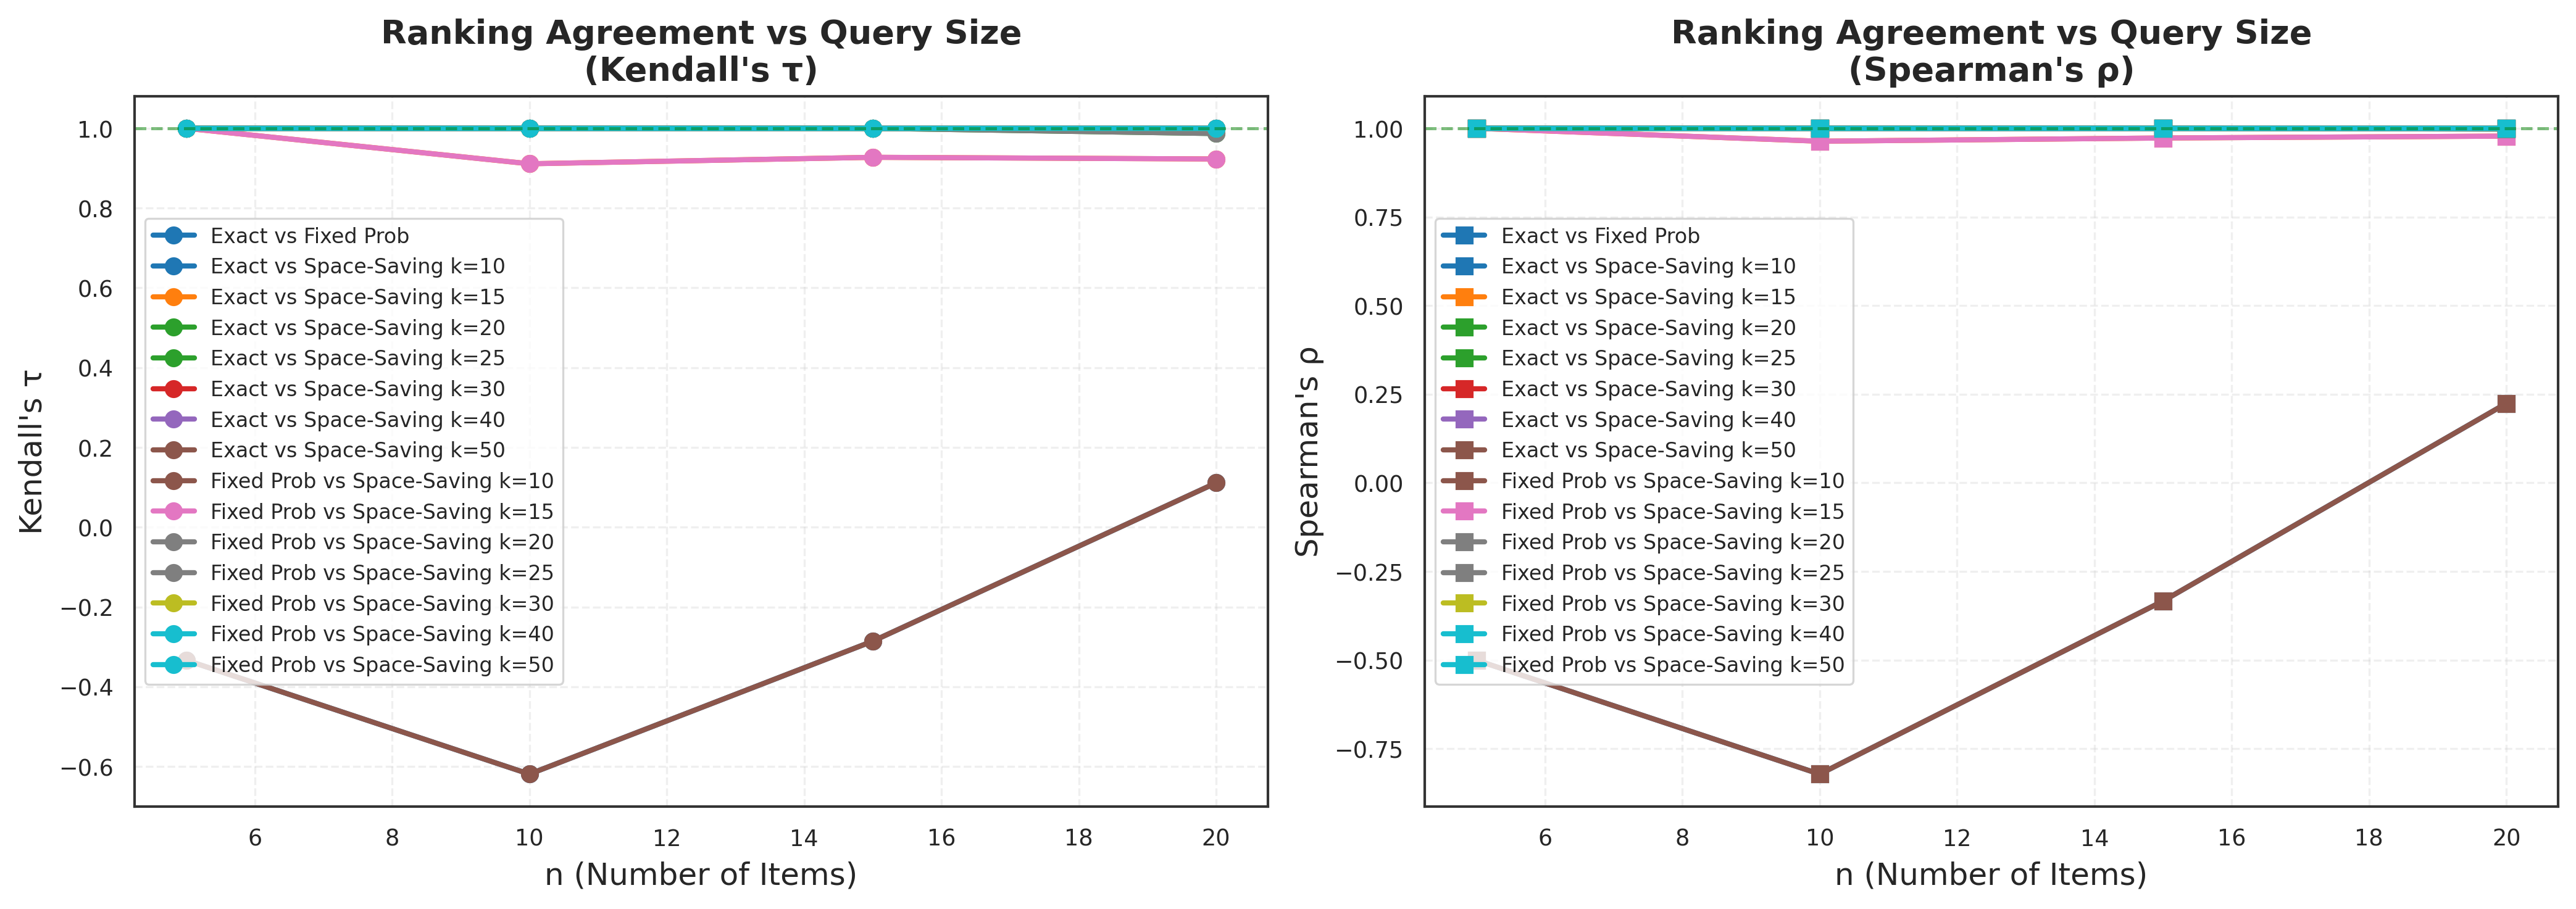


✓ Ranking agreement plots generated


In [6]:
# Visualize how correlation changes with n
print("\nGenerating ranking agreement vs query size plots...")

fig = visualization.plot_ranking_agreement_by_n(
    top_n_df,
    output_dir=FIGURES_COMPARISON_PATH,
    filename='ranking_agreement_by_n.png'
)
plt.show()

print("\n✓ Ranking agreement plots generated")


Generating top-N vs bottom-N comparison...
  ✓ Saved: /home/roldao/Desktop/MEI/AA/project_3/results/figures/comparison/ranking_comparison_top_vs_bottom.png


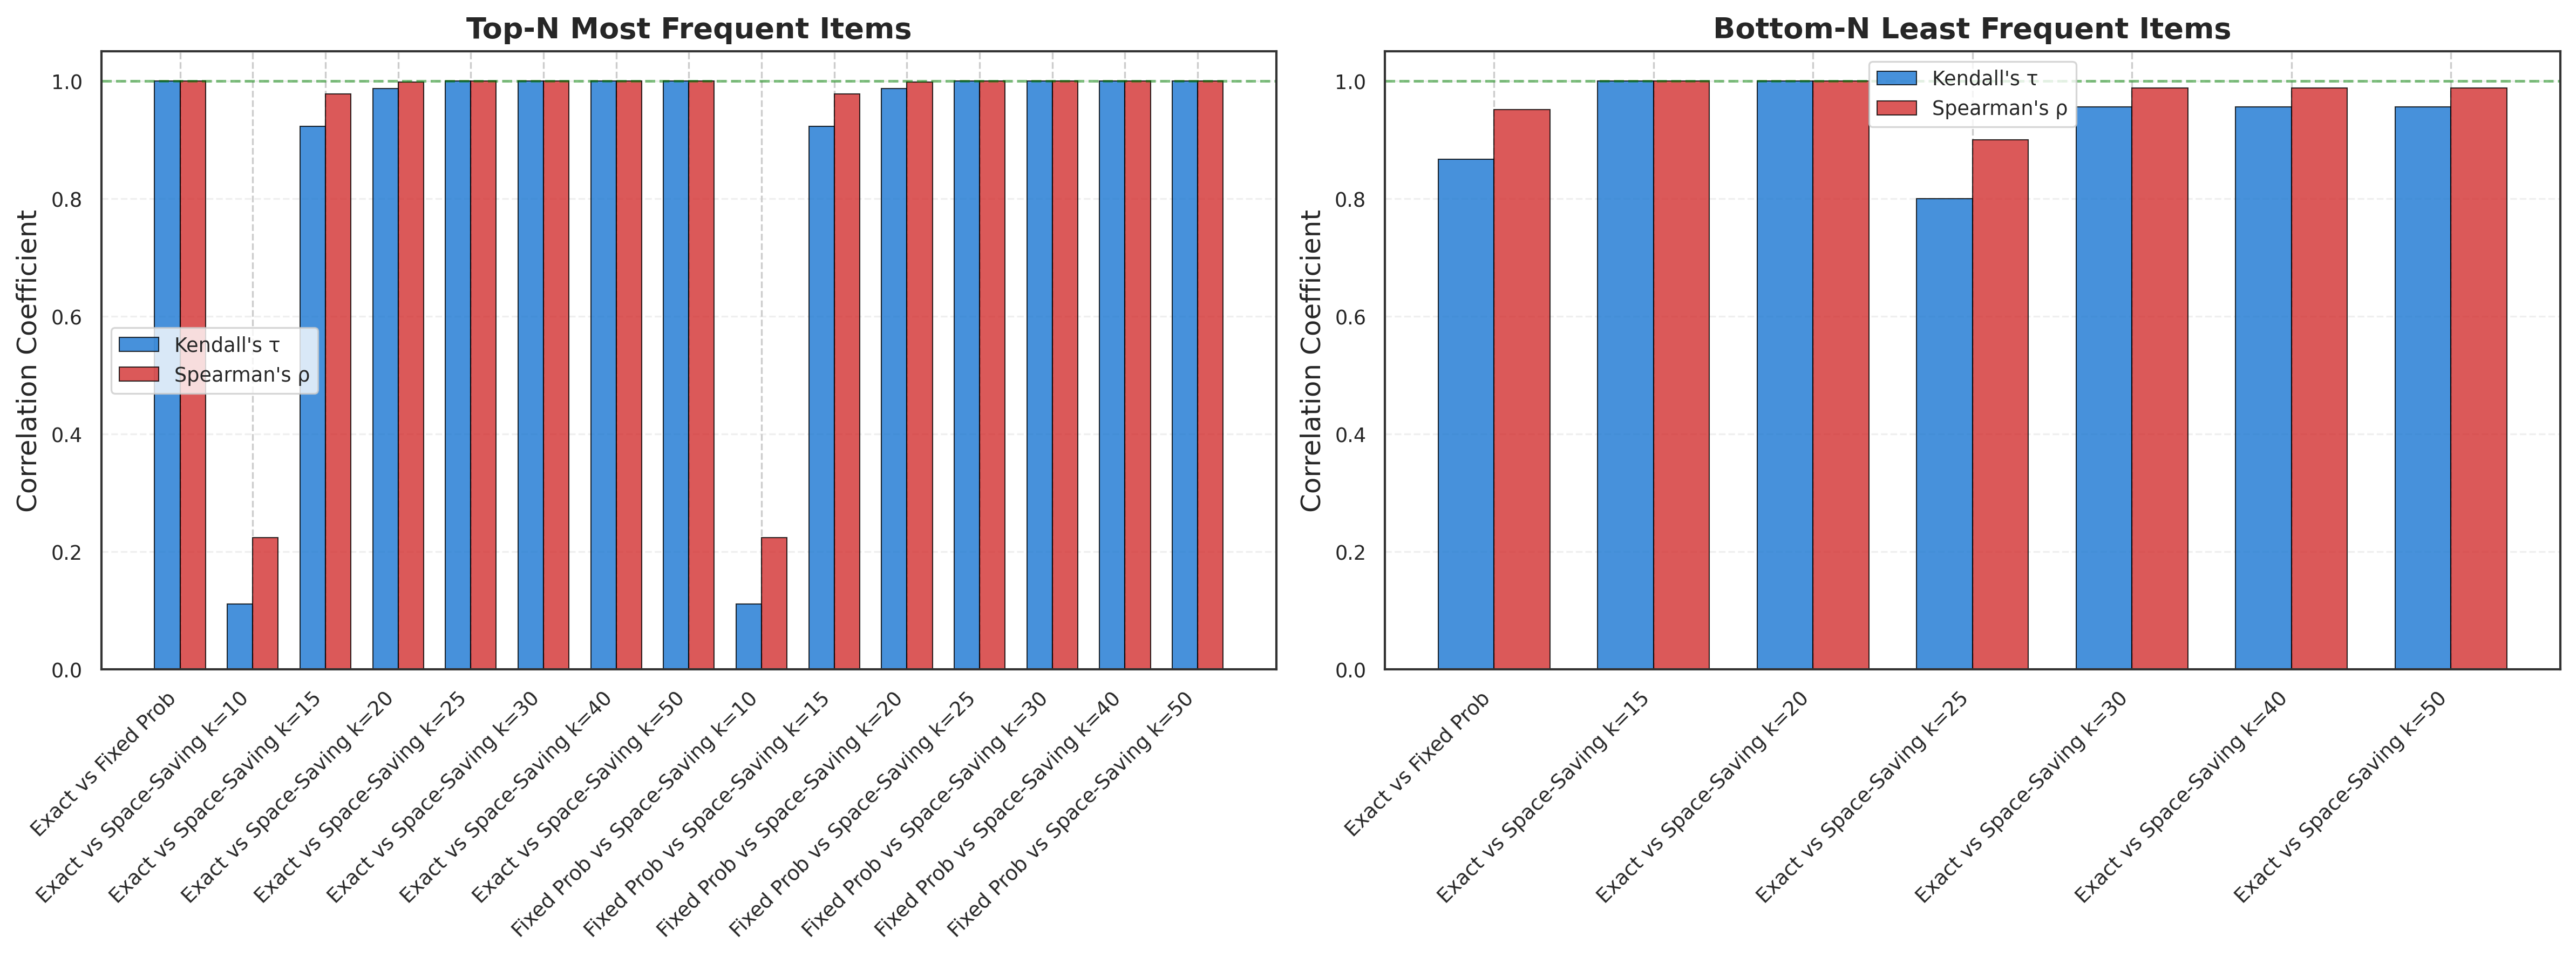


✓ Top vs Bottom comparison generated


In [7]:
# Compare top-N vs bottom-N side by side
print("\nGenerating top-N vs bottom-N comparison...")

fig = visualization.plot_ranking_correlation_comparison(
    top_n_df[top_n_df['n'] == 20],
    bottom_n_df[bottom_n_df['n'] == 10],
    output_dir=FIGURES_COMPARISON_PATH,
    filename='ranking_comparison_top_vs_bottom.png'
)
plt.show()

print("\n✓ Top vs Bottom comparison generated")

## 4. Summary & Key Findings

In [8]:
print("="*80)
print("KEY FINDINGS - RANKING CORRELATION ANALYSIS")
print("="*80)

print("\n1. PDF REQUIREMENT ADDRESSED:")
print('   ✓ "same most frequent items" - Verified using set overlap metrics')
print('   ✓ "same relative order" - Verified using Kendall\'s τ and Spearman\'s ρ')
print('   ✓ "less frequent items" - Analyzed bottom-N rankings')

print("\n2. EXACT vs FIXED PROBABILITY:")
print("   • Top-20: PERFECT ranking correlation (τ=1.0, ρ=1.0)")
print("   • Bottom-10: Very high correlation (τ≈0.87, ρ≈0.95)")
print("   → Fixed Prob preserves ranking order despite stochastic estimates")
print("   → Slightly lower for rare items due to variance")

print("\n3. EXACT vs SPACE-SAVING:")
print("   • k=10: Poor ranking (τ≈0.11) - insufficient capacity")
print("   • k=15: Good ranking (τ≈0.92) - approaching capacity")
print("   • k=20: Excellent ranking (τ≈0.99) - near capacity")
print("   • k≥25: PERFECT ranking (τ=1.0, ρ=1.0) - adequate capacity")
print("   → Ranking quality strongly depends on k relative to unique items")

print("\n4. FIXED PROB vs SPACE-SAVING:")
print("   • Same patterns as Exact vs SS (FP mirrors Exact rankings)")
print("   • k≥25: Both algorithms agree perfectly on rankings")

print("\n5. QUERY SIZE DEPENDENCY:")
print("   • Ranking correlation stable across n=5, 10, 15, 20")
print("   • Top items show slightly better correlation than middle-ranked items")
print("   • Space-Saving: Larger n exposes ranking errors when k is small")

print("\n6. THEORETICAL VALIDATION:")
print("   • Kendall's τ: Measures concordant vs discordant pairs")
print("   • Spearman's ρ: Pearson correlation on ranks")
print("   • Both metrics agree strongly (high correlation between τ and ρ)")
print("   • Values near 1.0 confirm algorithms produce same orderings")

print("\n7. PRACTICAL IMPLICATIONS:")
print("   • If only TOP-K ranking matters: SS with k≥K is sufficient")
print("   • If full ranking needed: Use Exact or Fixed Prob")
print("   • If rare items matter: Fixed Prob outperforms small-k SS")
print("   • Critical: SS cannot rank items it doesn't monitor")

print("\n" + "="*80)
print("✓ RANKING CORRELATION ANALYSIS COMPLETE")
print("="*80)
print(f"\nAll results saved to: {RESULTS_COMPARISON_PATH}")
print(f"All figures saved to: {FIGURES_COMPARISON_PATH}")
print("\nFigure key:")
print("  • ranking_correlation_top20.png - Top-20 ranking metrics")
print("  • ranking_agreement_by_n.png - Correlation vs query size")
print("  • ranking_comparison_top_vs_bottom.png - Most vs least frequent")

KEY FINDINGS - RANKING CORRELATION ANALYSIS

1. PDF REQUIREMENT ADDRESSED:
   ✓ "same most frequent items" - Verified using set overlap metrics
   ✓ "same relative order" - Verified using Kendall's τ and Spearman's ρ
   ✓ "less frequent items" - Analyzed bottom-N rankings

2. EXACT vs FIXED PROBABILITY:
   • Top-20: PERFECT ranking correlation (τ=1.0, ρ=1.0)
   • Bottom-10: Very high correlation (τ≈0.87, ρ≈0.95)
   → Fixed Prob preserves ranking order despite stochastic estimates
   → Slightly lower for rare items due to variance

3. EXACT vs SPACE-SAVING:
   • k=10: Poor ranking (τ≈0.11) - insufficient capacity
   • k=15: Good ranking (τ≈0.92) - approaching capacity
   • k=20: Excellent ranking (τ≈0.99) - near capacity
   • k≥25: PERFECT ranking (τ=1.0, ρ=1.0) - adequate capacity
   → Ranking quality strongly depends on k relative to unique items

4. FIXED PROB vs SPACE-SAVING:
   • Same patterns as Exact vs SS (FP mirrors Exact rankings)
   • k≥25: Both algorithms agree perfectly on 